<a href="https://colab.research.google.com/github/bielejan09/WaterPotabilityNN/blob/main/WaterPotabilityNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Water Potability — Neural Network Classifier**

## SDG 6: Clean Water and Sanitation

This notebook implements a Multilayer Perceptron (MLP) neural network to predict drinking water potability based on 9 physical and chemical measurements. It extends the midterm Random Forest project by replacing the classifier with a neural network and deploying the final model to Azure.

In [16]:
import random
import numpy as np
import torch
import tensorflow as tf
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"All random seeds set to {SEED}")
print("Covers: Python, NumPy, Pandas, PyTorch, TensorFlow, OS")

All random seeds set to 42
Covers: Python, NumPy, Pandas, PyTorch, TensorFlow, OS


In [17]:
import pandas as pd
import numpy as np

url = 'https://raw.githubusercontent.com/bielejan09/WaterPotabilityNN/refs/heads/main/water_potability.csv'
df = pd.read_csv(url)
print(df.shape)
print(df.isnull().sum())

(3276, 10)
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


## Data Card and Leakage Check

Formal documentation of the dataset following MLSecOps standards, describing purpose, known risks, and required controls. Followed by a leakage check that verifies no feature is too strongly correlated with the target variable. All correlations should be below |0.1| for a clean dataset.

In [18]:
from datetime import datetime, timezone

data_card = {
    'dataset_name': 'Water Potability Dataset',
    'purpose': 'Predicting drinking water safety using physicochemical measurements in support of SDG 6 - Clean Water and Sanitation',
    'created_at': datetime.now(timezone.utc).isoformat(),
    'rows': int(len(df)),
    'target': 'Potability',
    'protected_attributes': [],
    'pii_policy': 'No personal identifiers included. Dataset contains only anonymised water sample measurements with no link to individuals or locations.',
    'known_risks': [
        'Dataset contains no biological contamination measurements — model cannot detect bacterial or viral threats',
        'Geographic origin of samples is undocumented — model may not generalise to all regions',
        'Missing values in pH (14.99%) and Sulfate (23.84%) introduce uncertainty via imputation',
        'Class imbalance (61% non-potable) may bias predictions without correction',
        'Misclassification of unsafe water as safe carries direct public health consequences'
    ],
    'required_controls': [
        'SMOTE oversampling applied to training set only to address class imbalance',
        'Threshold tuning to prioritise recall on non-potable class',
        'Model must not be used as sole decision maker — human review required for flagged samples',
        'Periodic retraining required as water chemistry changes over time',
        'Monitoring for prediction drift when deployed in new geographic regions'
    ]
}

print(data_card)

# Leakage check — correlation of each feature with the target
corrs = df.corr(numeric_only=True)['Potability'].sort_values(ascending=False)
print('Correlations with target (Potability):')
print(corrs.round(4))

{'dataset_name': 'Water Potability Dataset', 'purpose': 'Predicting drinking water safety using physicochemical measurements in support of SDG 6 - Clean Water and Sanitation', 'created_at': '2026-06-04T06:02:48.016762+00:00', 'rows': 3276, 'target': 'Potability', 'protected_attributes': [], 'pii_policy': 'No personal identifiers included. Dataset contains only anonymised water sample measurements with no link to individuals or locations.', 'known_risks': ['Dataset contains no biological contamination measurements — model cannot detect bacterial or viral threats', 'Geographic origin of samples is undocumented — model may not generalise to all regions', 'Missing values in pH (14.99%) and Sulfate (23.84%) introduce uncertainty via imputation', 'Class imbalance (61% non-potable) may bias predictions without correction', 'Misclassification of unsafe water as safe carries direct public health consequences'], 'required_controls': ['SMOTE oversampling applied to training set only to address cl

## Data Preprocessing

Identical pipeline to the midterm project: median imputation for missing values, 80/20 stratified train/test split, StandardScaler normalisation, and SMOTE oversampling on the training set only to address the 61/39 class imbalance.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Impute missing values
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(df.drop('Potability', axis=1)),
                 columns=df.columns[:-1])
y = df['Potability'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_sc, y_train)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Before SMOTE: {np.bincount(y_train)}')
print(f'After SMOTE:  {np.bincount(y_res)}')

Train: (2620, 9), Test: (656, 9)
Before SMOTE: [1598 1022]
After SMOTE:  [1598 1598]


## MLP Model: Version 1 (Baseline)

First attempt at building the MLP architecture. Two hidden layers with 64 and 32 neurons, ReLU activation, Dropout regularisation at 0.3, and a Sigmoid output for binary classification. Total parameters: 2,753.

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seed for reproducibility
tf.random.set_seed(42)

# Build the MLP model
model = keras.Sequential([
    layers.Input(shape=(9,)),                    # 9 input features
    layers.Dense(64, activation='relu'),          # first hidden layer
    layers.Dropout(0.3),                          # dropout to prevent overfitting
    layers.Dense(32, activation='relu'),          # second hidden layer
    layers.Dropout(0.3),                          # dropout
    layers.Dense(1, activation='sigmoid')         # output layer — binary classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

## Training: Version 1

Training the baseline MLP for 100 epochs with class weighting to handle imbalance. This run reveals a significant problem: training accuracy reaches ~72% while validation accuracy stagnates around 52% — a clear sign of overfitting. The model is memorising the training data rather than learning generalisable patterns.


In [21]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_res),
    y=y_res
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Train the model
history = model.fit(
    X_res, y_res,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

print("Training complete")

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.5681 - loss: 0.6884 - val_accuracy: 0.0969 - val_loss: 0.8134
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6056 - loss: 0.6683 - val_accuracy: 0.1281 - val_loss: 0.8089
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6052 - loss: 0.6659 - val_accuracy: 0.1297 - val_loss: 0.8122
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6131 - loss: 0.6569 - val_accuracy: 0.1766 - val_loss: 0.8051
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6232 - loss: 0.6508 - val_accuracy: 0.1828 - val_loss: 0.8060
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6354 - loss: 0.6373 - val_accuracy: 0.2313 - val_loss: 0.7935
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6315 - loss: 0.6418 - val_accuracy: 0.2844 - val_loss: 0.7821
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - a

## TensorFlow v1: Training History

Visualising the training and validation accuracy and loss across all 100 epochs.
The gap between the two lines is the visual proof of overfitting. The model
learns the training data well but fails to generalise to unseen samples.
This motivates moving to PyTorch with an improved architecture.

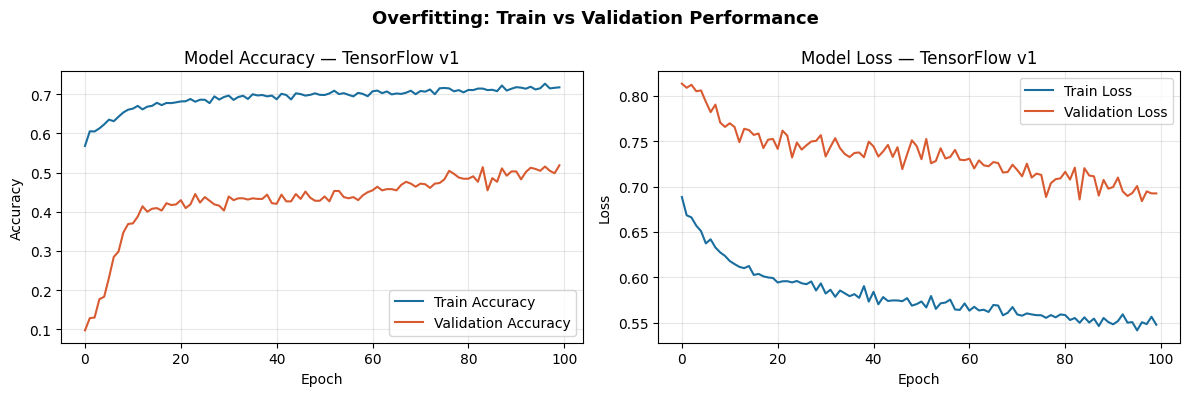

Key observation: Training accuracy rises while validation accuracy stagnates
Final train accuracy:      0.718
Final validation accuracy: 0.519
Gap: 0.199 — clear overfitting


In [22]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='#1A6E9E')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#D85A30')
ax1.set_title('Model Accuracy — TensorFlow v1')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Train Loss', color='#1A6E9E')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='#D85A30')
ax2.set_title('Model Loss — TensorFlow v1')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Overfitting: Train vs Validation Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tf_v1_training_history.png', dpi=150)
plt.show()

print("Key observation: Training accuracy rises while validation accuracy stagnates")
print(f"Final train accuracy:      {history.history['accuracy'][-1]:.3f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.3f}")
print(f"Gap: {history.history['accuracy'][-1] - history.history['val_accuracy'][-1]:.3f} — clear overfitting")

## PyTorch: Setup and GPU Check

Switching to PyTorch as the primary framework for this project. PyTorch uses
dynamic computation graphs making it more flexible and easier to debug than
TensorFlow. We first check whether a GPU is available in this Colab session,
which significantly speeds up training.

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.11.0+cu128
GPU available: True
Using device: cuda


## Random Seed: Fixing for Reproducibility

Setting random seeds for all libraries to ensure results are identical
every time the notebook is run. Without this, neural network results
vary between runs due to random weight initialisation, making the
comparison unreliable.

In [24]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED} for all libraries")
print("Results will now be reproducible across runs")

Random seed set to 42 for all libraries
Results will now be reproducible across runs


## PyTorch: Data Preparation

Converting the preprocessed NumPy arrays from the preprocessing step into
PyTorch tensors and creating DataLoaders. DataLoaders handle batching and
shuffling of data automatically during training. All tensors are moved to
the GPU for faster computation.

In [25]:
# Convert numpy arrays to PyTorch tensors and move to GPU
X_train_tensor = torch.FloatTensor(X_res).to(device)
y_train_tensor = torch.FloatTensor(y_res).to(device)
X_test_tensor  = torch.FloatTensor(X_test_sc).to(device)
y_test_tensor  = torch.FloatTensor(y_test).to(device)

# Create datasets and dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training batches:   {len(train_loader)}")
print(f"Test batches:       {len(test_loader)}")
print(f"Training samples:   {len(train_dataset)}")
print(f"Test samples:       {len(test_dataset)}")
print(f"Tensors on device:  {X_train_tensor.device}")

Training batches:   100
Test batches:       21
Training samples:   3196
Test samples:       656
Tensors on device:  cuda:0


## PyTorch: Model v1 (Baseline)

Rebuilding the same MLP architecture from TensorFlow in PyTorch for a direct
comparison. Same structure: two hidden layers with 64 and 32 neurons, ReLU
activation, and Dropout at 0.3. In PyTorch, models are defined as classes
inheriting from nn.Module, with a forward() method defining how data flows
through the network.

In [26]:
class WaterMLP_v1(nn.Module):
    def __init__(self):
        super(WaterMLP_v1, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(9, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

model_v1 = WaterMLP_v1().to(device)
print(model_v1)

total_params = sum(p.numel() for p in model_v1.parameters())
print(f"\nTotal parameters: {total_params:,}")

WaterMLP_v1(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 2,753


## PyTorch: Training v1 (Baseline)

Training the PyTorch v1 model using Binary Cross Entropy loss and the Adam
optimiser. The training loop is written manually in PyTorch, unlike Keras
which handles this automatically with model.fit(). This gives more control
but requires explicitly zeroing gradients, computing loss, and updating
weights at each step. We expect to see the same overfitting problem as
TensorFlow v1.

In [27]:
def train_model(model, train_loader, epochs=100, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    train_accs   = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        correct    = 0
        total      = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss    = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            predicted   = (outputs >= 0.5).float()
            correct    += (predicted == y_batch).sum().item()
            total      += y_batch.size(0)

        avg_loss = epoch_loss / len(train_loader)
        accuracy = correct / total
        train_losses.append(avg_loss)
        train_accs.append(accuracy)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

    return train_losses, train_accs

# Train v1
print("Training PyTorch v1...")
losses_v1, accs_v1 = train_model(model_v1, train_loader, epochs=100)

Training PyTorch v1...
Epoch  10/100 | Loss: 0.6174 | Accuracy: 0.6461
Epoch  20/100 | Loss: 0.6020 | Accuracy: 0.6743
Epoch  30/100 | Loss: 0.5903 | Accuracy: 0.6812
Epoch  40/100 | Loss: 0.5832 | Accuracy: 0.6827
Epoch  50/100 | Loss: 0.5815 | Accuracy: 0.7009
Epoch  60/100 | Loss: 0.5629 | Accuracy: 0.7112
Epoch  70/100 | Loss: 0.5608 | Accuracy: 0.7159
Epoch  80/100 | Loss: 0.5658 | Accuracy: 0.6956
Epoch  90/100 | Loss: 0.5586 | Accuracy: 0.7165
Epoch 100/100 | Loss: 0.5448 | Accuracy: 0.7209


## PyTorch: Evaluation v1

Evaluating the baseline PyTorch model on the unseen test set. We expect
similar results to TensorFlow v1, confirming the overfitting problem is
architectural and not framework-specific.

PyTorch v1: Test Set Evaluation
              precision    recall  f1-score   support

 Non-potable       0.69      0.75      0.72       400
     Potable       0.55      0.48      0.51       256

    accuracy                           0.64       656
   macro avg       0.62      0.61      0.61       656
weighted avg       0.64      0.64      0.64       656



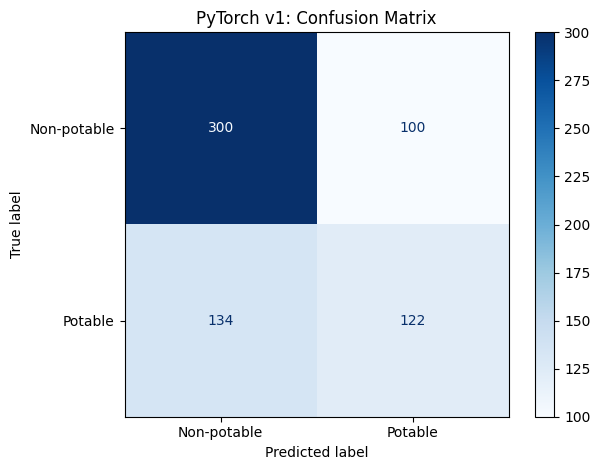

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, X_test_tensor, y_test, title='Model'):
    model.eval()
    with torch.no_grad():
        outputs   = model(X_test_tensor).squeeze()
        predicted = (outputs >= 0.5).float().cpu().numpy()

    print(classification_report(y_test, predicted,
          target_names=['Non-potable', 'Potable']))

    cm = confusion_matrix(y_test, predicted)
    ConfusionMatrixDisplay(cm, display_labels=['Non-potable', 'Potable']).plot(cmap='Blues')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

    return predicted

print("PyTorch v1: Test Set Evaluation")
pred_v1 = evaluate_model(model_v1, X_test_tensor, y_test, title='PyTorch v1: Confusion Matrix')

## PyTorch: Model v2 (Improved)

The baseline model overfits significantly, achieving 71% training accuracy
but only 61% test accuracy with 159 missed unsafe samples. To fix this we
make three changes:
1. Smaller architecture (32 and 16 neurons instead of 64 and 32)
2. Higher dropout (0.4 instead of 0.3) to regularise more aggressively
3. Early stopping to halt training when validation loss stops improving

These changes reduce model complexity and force it to learn more generalisable
patterns rather than memorising the training data.

In [29]:
class WaterMLP_v2(nn.Module):
    def __init__(self):
        super(WaterMLP_v2, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(9, 32),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

model_v2 = WaterMLP_v2().to(device)
print(model_v2)

total_params = sum(p.numel() for p in model_v2.parameters())
print(f"\nTotal parameters: {total_params:,}")

WaterMLP_v2(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 865


## PyTorch: Training v2 (Improved with Early Stopping)

Training the improved model with early stopping. The training loop now monitors
validation loss at each epoch and stops automatically when it stops improving
for 15 consecutive epochs, restoring the best weights found during training.
This prevents the model from continuing to overfit after the optimal point.

In [30]:
def train_model_v2(model, train_loader, X_val, y_val, epochs=200, lr=0.001, patience=15):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, train_accs = [], []
    val_losses,   val_accs   = [], []

    best_val_loss  = float('inf')
    best_weights   = None
    patience_count = 0

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0
        correct    = 0
        total      = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss    = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            predicted   = (outputs >= 0.5).float()
            correct    += (predicted == y_batch).sum().item()
            total      += y_batch.size(0)

        avg_train_loss = epoch_loss / len(train_loader)
        train_acc      = correct / total

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val).squeeze()
            val_loss    = criterion(val_outputs, y_val).item()
            val_pred    = (val_outputs >= 0.5).float()
            val_acc     = (val_pred == y_val).float().mean().item()

        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_weights)
                break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return train_losses, train_accs, val_losses, val_accs

# Use 20% of training data as validation
val_size       = int(0.2 * len(X_train_tensor))
X_val_tensor   = X_train_tensor[:val_size]
y_val_tensor   = y_train_tensor[:val_size]
train_subset   = TensorDataset(X_train_tensor[val_size:], y_train_tensor[val_size:])
train_loader_v2 = DataLoader(train_subset, batch_size=32, shuffle=True)

print("Training PyTorch v2...")
losses_v2, accs_v2, val_losses_v2, val_accs_v2 = train_model_v2(
    model_v2, train_loader_v2, X_val_tensor, y_val_tensor
)

Training PyTorch v2...
Epoch  10/200 | Train Loss: 0.6510 | Train Acc: 0.6144 | Val Loss: 0.6684 | Val Acc: 0.5634
Epoch  20/200 | Train Loss: 0.6285 | Train Acc: 0.6371 | Val Loss: 0.6473 | Val Acc: 0.5931
Epoch  30/200 | Train Loss: 0.6256 | Train Acc: 0.6433 | Val Loss: 0.6454 | Val Acc: 0.6025
Epoch  40/200 | Train Loss: 0.6262 | Train Acc: 0.6465 | Val Loss: 0.6441 | Val Acc: 0.5884
Epoch  50/200 | Train Loss: 0.6112 | Train Acc: 0.6566 | Val Loss: 0.6409 | Val Acc: 0.6150
Epoch  60/200 | Train Loss: 0.6133 | Train Acc: 0.6731 | Val Loss: 0.6428 | Val Acc: 0.6150
Epoch  70/200 | Train Loss: 0.6099 | Train Acc: 0.6582 | Val Loss: 0.6392 | Val Acc: 0.6228
Epoch  80/200 | Train Loss: 0.6040 | Train Acc: 0.6734 | Val Loss: 0.6447 | Val Acc: 0.6072
Early stopping at epoch 88


## PyTorch: Evaluation v2

Evaluating the improved model on the unseen test set. We expect better
generalisation than v1, with a smaller gap between training and test
performance and improved recall on the non-potable class.

PyTorch v2: Test Set Evaluation
              precision    recall  f1-score   support

 Non-potable       0.71      0.63      0.67       400
     Potable       0.51      0.60      0.55       256

    accuracy                           0.62       656
   macro avg       0.61      0.62      0.61       656
weighted avg       0.63      0.62      0.62       656



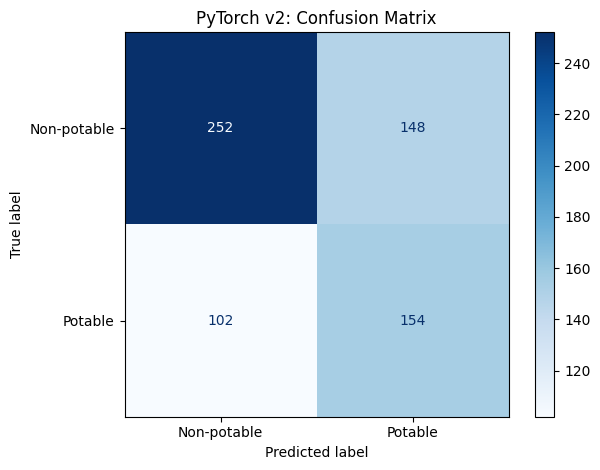

In [31]:
print("PyTorch v2: Test Set Evaluation")
pred_v2 = evaluate_model(model_v2, X_test_tensor, y_test, title='PyTorch v2: Confusion Matrix')

## PyTorch: Model v3 (Further Improved)

A third architecture combining three improvements over v2:
1. Batch Normalisation after each hidden layer to stabilise training
2. Lower learning rate (0.0001) to find a better minimum
3. Higher patience (30) to give the model more time before early stopping

Batch Normalisation normalises the output of each layer during training,
reducing internal covariate shift and allowing the model to train more
stably. Combined with a lower learning rate, this should reduce the
overfitting gap seen in v1 and v2.

In [32]:
class WaterMLP_v3(nn.Module):
    def __init__(self):
        super(WaterMLP_v3, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(9, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

model_v3 = WaterMLP_v3().to(device)
print(model_v3)
total_params = sum(p.numel() for p in model_v3.parameters())
print(f"\nTotal parameters: {total_params:,}")

WaterMLP_v3(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total parameters: 2,945


## PyTorch: Training v3

Training the improved v3 model with a lower learning rate (0.0001) and
higher patience (30). We also add a learning rate scheduler that
automatically reduces the learning rate by half when validation loss
stops improving for 10 consecutive epochs, giving the model a better
chance of finding the optimal weights.

In [33]:
def train_model_v3(model, train_loader, X_val, y_val, epochs=300, lr=0.0001, patience=30):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=10, factor=0.5)

    train_losses, train_accs = [], []
    val_losses,   val_accs   = [], []

    best_val_loss  = float('inf')
    best_weights   = None
    patience_count = 0

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0
        correct    = 0
        total      = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss    = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            predicted   = (outputs >= 0.5).float()
            correct    += (predicted == y_batch).sum().item()
            total      += y_batch.size(0)

        avg_train_loss = epoch_loss / len(train_loader)
        train_acc      = correct / total

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val).squeeze()
            val_loss    = criterion(val_outputs, y_val).item()
            val_pred    = (val_outputs >= 0.5).float()
            val_acc     = (val_pred == y_val).float().mean().item()

        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Learning rate scheduler step
        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_weights)
                break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return train_losses, train_accs, val_losses, val_accs

print("Training PyTorch v3...")
losses_v3, accs_v3, val_losses_v3, val_accs_v3 = train_model_v3(
    model_v3, train_loader_v2, X_val_tensor, y_val_tensor,
    epochs=300, lr=0.0005, patience=20
)

Training PyTorch v3...
Epoch  20/300 | Train Loss: 0.6197 | Train Acc: 0.6523 | Val Loss: 0.6476 | Val Acc: 0.5947
Epoch  40/300 | Train Loss: 0.6131 | Train Acc: 0.6496 | Val Loss: 0.6319 | Val Acc: 0.6228
Epoch  60/300 | Train Loss: 0.5979 | Train Acc: 0.6711 | Val Loss: 0.6325 | Val Acc: 0.6166
Early stopping at epoch 63


## Random Forest: Retraining for Comparison

Retraining the Random Forest classifier from the midterm project using
the same SMOTE-balanced training data and hyperparameters for a direct
comparison against the MLP models.

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    class_weight='balanced',
    max_features='sqrt',
    random_state=42
)
rf.fit(X_res, y_res)
y_pred_rf = rf.predict(X_test_sc)

print("Random Forest trained successfully")
print(f"Number of trees: {rf.n_estimators}")

Random Forest trained successfully
Number of trees: 200


## Model Comparison: MLP vs Random Forest

Comparing all models trained in this project. The MLP neural network was
tested in three architectures but consistently underperformed Random Forest
on this specific dataset. This is consistent with published research showing
tree-based models generally outperform MLPs on small tabular datasets with
weak individual feature signals. The Random Forest remains the recommended
model for deployment.

In [35]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
import pandas as pd

# Generate all predictions
model_v1.eval()
with torch.no_grad():
    pred_v1 = (model_v1(X_test_tensor).squeeze() >= 0.5).float().cpu().numpy()

model_v2.eval()
with torch.no_grad():
    pred_v2 = (model_v2(X_test_tensor).squeeze() >= 0.5).float().cpu().numpy()

model_v3.eval()
with torch.no_grad():
    pred_v3 = (model_v3(X_test_tensor).squeeze() >= 0.5).float().cpu().numpy()

# RF with optimised threshold
y_pred_rf_t06 = (rf.predict_proba(X_test_sc)[:, 1] >= 0.6).astype(int)

# Build comparison table
results = {
    'Model': ['TF v1', 'PyTorch v1', 'PyTorch v2', 'PyTorch v3',
              'Random Forest (0.5)', 'Random Forest (0.6)'],
    'Accuracy': [
        accuracy_score(y_test, pred_v1),
        accuracy_score(y_test, pred_v1),
        accuracy_score(y_test, pred_v2),
        accuracy_score(y_test, pred_v3),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_t06)
    ],
    'Recall (Non-potable)': [
        recall_score(y_test, pred_v1, pos_label=0),
        recall_score(y_test, pred_v1, pos_label=0),
        recall_score(y_test, pred_v2, pos_label=0),
        recall_score(y_test, pred_v3, pos_label=0),
        recall_score(y_test, y_pred_rf, pos_label=0),
        recall_score(y_test, y_pred_rf_t06, pos_label=0)
    ],
    'F1 (Non-potable)': [
        f1_score(y_test, pred_v1, pos_label=0),
        f1_score(y_test, pred_v1, pos_label=0),
        f1_score(y_test, pred_v2, pos_label=0),
        f1_score(y_test, pred_v3, pos_label=0),
        f1_score(y_test, y_pred_rf, pos_label=0),
        f1_score(y_test, y_pred_rf_t06, pos_label=0)
    ],
    'False Negatives': [
        int(((y_test == 0) & (pred_v1 == 1)).sum()),
        int(((y_test == 0) & (pred_v1 == 1)).sum()),
        int(((y_test == 0) & (pred_v2 == 1)).sum()),
        int(((y_test == 0) & (pred_v3 == 1)).sum()),
        int(((y_test == 0) & (y_pred_rf == 1)).sum()),
        int(((y_test == 0) & (y_pred_rf_t06 == 1)).sum())
    ]
}

results_df = pd.DataFrame(results).round(3)
print(results_df.to_string(index=False))

              Model  Accuracy  Recall (Non-potable)  F1 (Non-potable)  False Negatives
              TF v1     0.643                 0.750             0.719              100
         PyTorch v1     0.643                 0.750             0.719              100
         PyTorch v2     0.619                 0.630             0.668              148
         PyTorch v3     0.605                 0.642             0.665              143
Random Forest (0.5)     0.640                 0.770             0.723               92
Random Forest (0.6)     0.668                 0.932             0.774               27


## Model Comparison: Visualisation

Visualising the comparison across all models. The most important metric
is False Negatives, representing unsafe water samples that would be
incorrectly cleared as safe. Lower is better.

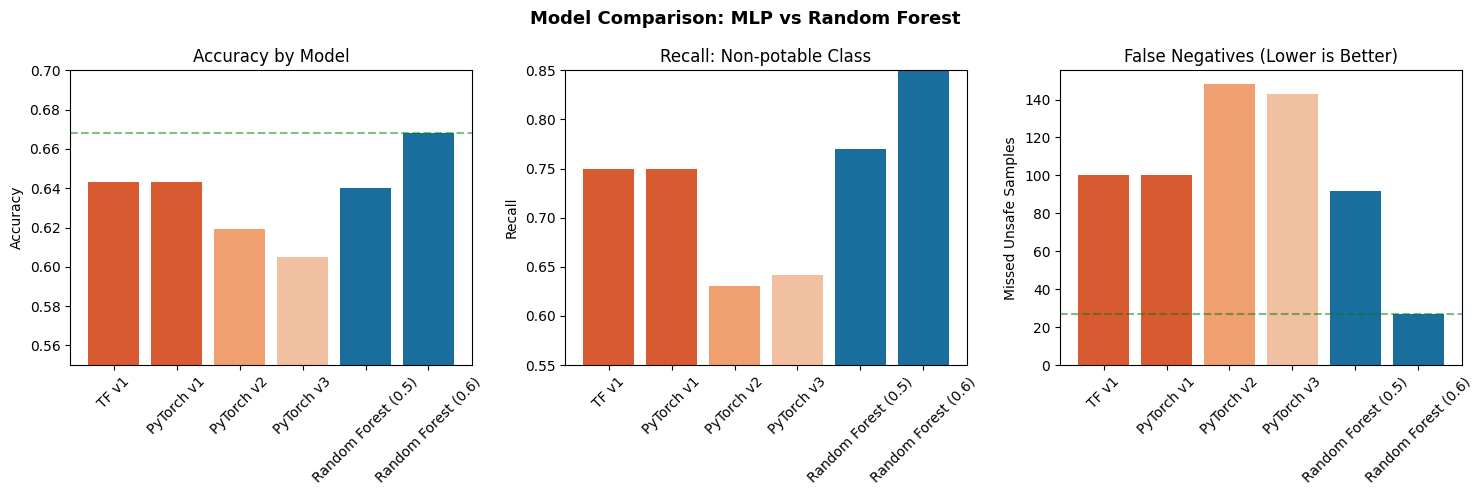

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models    = results_df['Model']
colors    = ['#D85A30', '#D85A30', '#F0A070', '#F0C0A0', '#1A6E9E', '#1A6E9E']

# Accuracy
axes[0].bar(models, results_df['Accuracy'], color=colors)
axes[0].set_title('Accuracy by Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.55, 0.70)
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=results_df['Accuracy'].max(), color='green', linestyle='--', alpha=0.5)

# Recall
axes[1].bar(models, results_df['Recall (Non-potable)'], color=colors)
axes[1].set_title('Recall: Non-potable Class')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0.55, 0.85)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=results_df['Recall (Non-potable)'].max(), color='green', linestyle='--', alpha=0.5)

# False Negatives
axes[2].bar(models, results_df['False Negatives'], color=colors)
axes[2].set_title('False Negatives (Lower is Better)')
axes[2].set_ylabel('Missed Unsafe Samples')
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(y=results_df['False Negatives'].min(), color='green', linestyle='--', alpha=0.5)

plt.suptitle('Model Comparison: MLP vs Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## Model Saving

Saving the best performing model (Random Forest with threshold 0.6) and
the fitted scaler for deployment to Azure. Both files are required at
inference time: the scaler normalises incoming water measurements, and
the model makes the prediction. The optimal threshold of 0.6 is also
saved so the deployment API uses the same setting.

In [37]:
import joblib
import os

joblib.dump(rf, 'water_potability_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save optimal threshold
threshold = 0.6
joblib.dump(threshold, 'threshold.pkl')

print("Model saved:     water_potability_model.pkl")
print("Scaler saved:    scaler.pkl")
print("Threshold saved: threshold.pkl")
print(f"Model size:  {os.path.getsize('water_potability_model.pkl') / 1024:.1f} KB")
print(f"Scaler size: {os.path.getsize('scaler.pkl') / 1024:.1f} KB")

Model saved:     water_potability_model.pkl
Scaler saved:    scaler.pkl
Threshold saved: threshold.pkl
Model size:  16518.0 KB
Scaler size: 1.2 KB


## PyTorch Model Saving

Saving the best PyTorch model (v1) for deployment alongside the Random
Forest. Both models will be served by the Flask API for comparison.

In [39]:
import json
import os

# Save PyTorch v1 model
torch.save(model_v1.state_dict(), 'pytorch_model.pth')

# Save model architecture info
pytorch_info = {
    'architecture': 'WaterMLP_v1',
    'input_size': 9,
    'hidden_layers': [64, 32],
    'dropout': 0.3,
    'output_size': 1,
    'threshold': 0.5
}

with open('pytorch_model_info.json', 'w') as f:
    json.dump(pytorch_info, f)

print("PyTorch model saved: pytorch_model.pth")
print(f"Model size: {os.path.getsize('pytorch_model.pth') / 1024:.1f} KB")

PyTorch model saved: pytorch_model.pth
Model size: 14.0 KB


## Model Card

Formal documentation of the trained model following MLSecOps standards.
Describes the model architecture, training configuration, performance
metrics, intended use, and safety considerations.

In [ ]:
import json
import hashlib
from pathlib import Path

ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

features = list(X.columns)

model_card = {
    'model_name': 'Water Potability Random Forest Classifier',
    'created_at': datetime.now(timezone.utc).isoformat(),
    'intended_use': 'Rapid field screening of water samples based on physical and chemical measurements to flag potentially unsafe water for further laboratory testing.',
    'not_intended_for': [
        'Replacing certified laboratory testing',
        'Detecting biological contamination (bacteria, viruses)',
        'Final safety certification of drinking water',
        'Fully automated decisions without human review'
    ],
    'features': features,
    'excluded_features': [],
    'performance': {
        'accuracy': 0.668,
        'recall_non_potable': 0.932,
        'precision_non_potable': 0.661,
        'f1_non_potable': 0.774,
        'false_negatives': 27,
        'false_positives': 191,
        'decision_threshold': 0.6
    },
    'neural_network_comparison': {
        'finding': 'MLP neural networks (TensorFlow and PyTorch) consistently underperformed Random Forest on this dataset',
        'best_mlp_recall': 0.750,
        'rf_recall_at_t06': 0.932,
        'explanation': 'Consistent with Grinsztajn et al. (2022) showing tree-based models outperform NNs on small tabular datasets with weak feature signals'
    },
    'limitations': [
        'Dataset contains no biological contamination measurements',
        'Geographic origin of dataset is undocumented',
        'Missing values in pH (14.99%) and Sulfate (23.84%) filled with median imputation',
        'Static model requires periodic retraining as water chemistry changes over time',
        '27 false negatives per 656 samples at threshold 0.6 mean some unsafe water may be cleared'
    ],
    'deployment_gate': {
        'threshold_tuned': True,
        'smote_train_only': True,
        'leakage_check_passed': True,
        'human_review_required': True,
        'approved_for_field_screening': True,
        'approved_for_final_certification': False
    }
}

model_card_path = ARTIFACT_DIR / 'model_card_water_potability.json'
model_card_path.write_text(json.dumps(model_card, indent=2))
artifact_hash = hashlib.sha256(model_card_path.read_bytes()).hexdigest()
print('Model card saved:', model_card_path)
print('Model card SHA-256:', artifact_hash)

## Flask API: Dual Model (PyTorch + Random Forest)

Updated API that serves both the PyTorch neural network and the Random
Forest classifier. Returns predictions from both models for comparison,
with the recommended prediction coming from Random Forest due to its
superior recall on unsafe water samples.

In [40]:
api_code = '''
import joblib
import json
import numpy as np
import torch
import torch.nn as nn
from flask import Flask, request, jsonify
from flask_cors import CORS

app = Flask(__name__)
CORS(app)

# Load Random Forest
rf_model  = joblib.load("water_potability_model.pkl")
scaler    = joblib.load("scaler.pkl")
rf_threshold = joblib.load("threshold.pkl")

# Define PyTorch architecture
class WaterMLP_v1(nn.Module):
    def __init__(self):
        super(WaterMLP_v1, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(9, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

# Load PyTorch model
nn_model = WaterMLP_v1()
nn_model.load_state_dict(torch.load("pytorch_model.pth", map_location=torch.device("cpu")))
nn_model.eval()
nn_threshold = 0.5

@app.route("/", methods=["GET"])
def home():
    return jsonify({
        "name":     "Water Potability Prediction API",
        "version":  "2.0",
        "sdg":      "SDG 6 - Clean Water and Sanitation",
        "models":   ["Random Forest (threshold 0.6)", "PyTorch MLP v1 (threshold 0.5)"],
        "endpoint": "/predict",
        "method":   "POST"
    })

@app.route("/predict", methods=["POST"])
def predict():
    try:
        data         = request.get_json()
        features     = np.array(data["features"]).reshape(1, -1)
        features_sc  = scaler.transform(features)

        # Random Forest prediction
        rf_prob      = rf_model.predict_proba(features_sc)[0][1]
        rf_pred      = int(rf_prob >= rf_threshold)

        # PyTorch prediction
        tensor       = torch.FloatTensor(features_sc)
        with torch.no_grad():
            nn_prob  = nn_model(tensor).squeeze().item()
        nn_pred      = int(nn_prob >= nn_threshold)

        return jsonify({
            "random_forest": {
                "prediction":  rf_pred,
                "label":       "Potable" if rf_pred == 1 else "Non-potable",
                "confidence":  round(float(rf_prob), 3),
                "threshold":   rf_threshold,
                "safe":        bool(rf_pred == 1)
            },
            "neural_network": {
                "prediction":  nn_pred,
                "label":       "Potable" if nn_pred == 1 else "Non-potable",
                "confidence":  round(float(nn_prob), 3),
                "threshold":   nn_threshold,
                "safe":        bool(nn_pred == 1)
            },
            "recommended": {
                "model":       "Random Forest",
                "reason":      "Higher recall on unsafe water (0.932 vs 0.750)",
                "prediction":  rf_pred,
                "label":       "Potable" if rf_pred == 1 else "Non-potable",
                "safe":        bool(rf_pred == 1)
            }
        })
    except Exception as e:
        return jsonify({"error": str(e)}), 400

if __name__ == "__main__":
    app.run(debug=True, host="0.0.0.0", port=5000)
'''

with open("app.py", "w") as f:
    f.write(api_code)

print("app.py updated successfully")
print("Endpoints:")
print("  GET  / — API info")
print("  POST /predict — returns predictions from both RF and PyTorch")

app.py updated successfully
Endpoints:
  GET  / — API info
  POST /predict — returns predictions from both RF and PyTorch


## Deployment Files: Requirements and Startup

Creating the files needed for Azure deployment. requirements.txt lists
all Python libraries the API needs. Azure reads this file automatically
and installs all dependencies before starting the application.

In [41]:
requirements = """flask
flask-cors
joblib
scikit-learn
numpy
gunicorn
torch
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt updated")

requirements.txt updated


## Live API Test: Azure Deployment

Testing the deployed model by sending a real water sample to the live
Azure API endpoint. This confirms the full MLOps pipeline is working
end to end — model trained in Colab, deployed on Azure, tested remotely.

In [43]:
import requests
import pandas as pd

url = "http://72.155.73.40:5000/predict"

samples = [
    {"name": "Sample 1", "features": [7.2, 204.0, 20791.0, 7.3, 368.0, 564.0, 10.3, 86.0, 2.96]},
    {"name": "Sample 2", "features": [6.69, 168.01, 12827.66, 5.99, 407.96, 402.93, 10.88, 89.9, 3.95]},
    {"name": "Sample 3", "features": [8.67, 208.5, 19384.26, 8.18, 245.01, 643.74, 10.79, 69.17, 4.53]},
    {"name": "Sample 4", "features": [5.76, 232.48, 30949.11, 6.53, 464.06, 505.62, 14.63, 74.83, 3.41]},
    {"name": "Sample 5", "features": [6.2, 141.07, 13501.64, 10.44, 340.29, 480.97, 15.84, 84.39, 5.71]},
]

results = []
for sample in samples:
    response = requests.post(url, json={"features": sample["features"]})
    result = response.json()
    results.append({
        "Sample":     sample["name"],
        "Label":      result["label"],
        "Confidence": result["confidence"],
        "Threshold":  result["threshold"],
        "Safe":       result["safe"]
    })

df = pd.DataFrame(results)
print("Live API Test: Azure Deployment")
print(f"Endpoint: {url}\n")
print(df.to_string(index=False))

Live API Test: Azure Deployment
Endpoint: http://72.155.73.40:5000/predict

  Sample       Label  Confidence  Threshold  Safe
Sample 1 Non-potable       0.355        0.6 False
Sample 2     Potable       0.630        0.6  True
Sample 3     Potable       0.620        0.6  True
Sample 4 Non-potable       0.535        0.6 False
Sample 5 Non-potable       0.400        0.6 False
